# 집회일 기준 교통량·지하철 이용량 비교
- 교통량: `서강대교`, `마포대교`, `원효대교`의 시간대별 평균
- 지하철 이용량: `여의도`, `여의나루`의 승·하차 평균
- 기준선: 집회일이 속한 `당월`의 `동일 요일군(평일/주말)` 평균
- 겹쳐 그리는 선: 기준선(평균), 최대값, 중앙값, 최소값

아래 `event_dates`만 바꾸면 다른 집회일도 같은 방식으로 다시 그릴 수 있습니다.

In [1]:
from pathlib import Path
import platform
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / 'Data').exists() and (project_root.parent / 'Data').exists():
    project_root = project_root.parent

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 140

selected_bridges = ['서강대교', '마포대교', '원효대교']
selected_stations = ['여의도', '여의나루']
weekday_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}

event_dates = pd.DataFrame({
    '집회일': pd.to_datetime([
        '2023-02-26',
        '2023-09-02',
        '2023-09-23',
        '2024-11-17',
        '2024-12-07',
        '2024-12-14',
    ])
})
event_dates['연도'] = event_dates['집회일'].dt.year
event_dates['월'] = event_dates['집회일'].dt.month
event_dates['요일'] = event_dates['집회일'].dt.weekday.map(weekday_map)
event_dates['구분'] = event_dates['집회일'].dt.weekday.map(lambda x: '주말' if x >= 5 else '평일')
display(event_dates)

,집회일,연도,월,요일,구분
0,2023-02-26,2023,2,일,주말
1,2023-09-02,2023,9,토,주말
2,2023-09-23,2023,9,토,주말
3,2024-11-17,2024,11,일,주말
4,2024-12-07,2024,12,토,주말
5,2024-12-14,2024,12,토,주말


In [2]:
traffic_time_order = [f'{hour}시' for hour in range(24)]
subway_time_order = [
    '06시이전', '06시 이전', '06-07시간대', '06시-07시', '07-08시간대', '07시-08시',
    '08-09시간대', '08시-09시', '09-10시간대', '09시-10시', '10-11시간대', '10시-11시',
    '11-12시간대', '11시-12시', '12-13시간대', '12시-13시', '13-14시간대', '13시-14시',
    '14-15시간대', '14시-15시', '15-16시간대', '15시-16시', '16-17시간대', '16시-17시',
    '17-18시간대', '17시-18시', '18-19시간대', '18시-19시', '19-20시간대', '19시-20시',
    '20-21시간대', '20시-21시', '21-22시간대', '21시-22시', '22-23시간대', '22시-23시',
    '23-24시간대', '23시-24시', '24시이후', '24시 이후'
]


def compact_subway_label(label):
    normalized = label.replace(' ', '')
    if normalized == '06시이전':
        return '06시 이전'
    if normalized == '24시이후':
        return '24시 이후'

    compact = normalized.replace('시간대', '')
    compact = compact.replace('시-', '-')
    if '-' in compact and compact.endswith('시'):
        compact = compact[:-1]
    return compact


def load_traffic_daily(year):
    traffic_path = project_root / 'Data' / 'Trafficdata' / f'traffic_{str(year)[-2:]}.csv'
    traffic_df = pd.read_csv(traffic_path)
    traffic_df['일자'] = pd.to_datetime(traffic_df['일자'].astype(str), format='%Y%m%d')
    hour_cols = [col for col in traffic_time_order if col in traffic_df.columns]

    daily_df = (
        traffic_df[traffic_df['지점명'].isin(selected_bridges)]
        .groupby('일자', as_index=False)[hour_cols]
        .mean()
    )
    daily_df['연도'] = daily_df['일자'].dt.year
    daily_df['월'] = daily_df['일자'].dt.month
    daily_df['구분'] = daily_df['일자'].dt.weekday.map(lambda x: '주말' if x >= 5 else '평일')
    tick_labels = [f'{int(col[:-1]):02d}시' for col in hour_cols]
    return daily_df, hour_cols, tick_labels


def load_subway_daily(year):
    file_name = (
        '서울교통공사_역별 시간대별 승하차인원(23.1~23.12) (1).csv'
        if year == 2023
        else '서울교통공사_역별 시간대별 승하차인원(24.1~24.12) (1).csv'
    )
    subway_path = project_root / 'Data' / 'Metro' / file_name
    subway_df = pd.read_csv(subway_path, encoding='cp949')

    date_col = '수송일자' if '수송일자' in subway_df.columns else '날짜'
    hour_cols = [col for col in subway_time_order if col in subway_df.columns]

    daily_df = (
        subway_df[subway_df['역명'].isin(selected_stations)]
        .assign(**{date_col: lambda x: pd.to_datetime(x[date_col])})
        .groupby(date_col, as_index=False)[hour_cols]
        .mean()
        .rename(columns={date_col: '일자'})
    )
    daily_df['연도'] = daily_df['일자'].dt.year
    daily_df['월'] = daily_df['일자'].dt.month
    daily_df['구분'] = daily_df['일자'].dt.weekday.map(lambda x: '주말' if x >= 5 else '평일')
    tick_labels = [compact_subway_label(col) for col in hour_cols]
    return daily_df, hour_cols, tick_labels


def normalize_panel_stats(stats_df):
    numeric_stats_df = stats_df.astype(float)
    min_value = numeric_stats_df.min().min()
    max_value = numeric_stats_df.max().max()

    if pd.isna(min_value) or pd.isna(max_value) or min_value == max_value:
        return numeric_stats_df * 0.0

    return (numeric_stats_df - min_value) / (max_value - min_value)


def build_monthly_stats(daily_df, hour_cols, event_date):
    stat_order = ['집회일 실측값', '기준선(평균)', '최대값', '중앙값', '최소값']
    if daily_df.empty:
        empty_df = pd.DataFrame(index=stat_order, columns=hour_cols, dtype=float)
        return empty_df.fillna(0.0)

    event_mask = daily_df['일자'].dt.normalize() == pd.Timestamp(event_date).normalize()
    if event_mask.any():
        event_profile = daily_df.loc[event_mask, hour_cols].iloc[0].astype(float)
    else:
        event_profile = pd.Series(index=hour_cols, dtype=float)

    stats_df = pd.DataFrame({
        '집회일 실측값': event_profile,
        '기준선(평균)': daily_df[hour_cols].mean(),
        '최대값': daily_df[hour_cols].max(),
        '중앙값': daily_df[hour_cols].median(),
        '최소값': daily_df[hour_cols].min(),
    }).T
    return normalize_panel_stats(stats_df.loc[stat_order])


In [3]:
traffic_data = {year: load_traffic_daily(year) for year in sorted(event_dates['연도'].unique())}
subway_data = {year: load_subway_daily(year) for year in sorted(event_dates['연도'].unique())}

comparison_rows = []
for event in event_dates.itertuples(index=False):
    traffic_daily_df, _, _ = traffic_data[event.연도]
    subway_daily_df, _, _ = subway_data[event.연도]

    traffic_subset = traffic_daily_df[(traffic_daily_df['월'] == event.월) & (traffic_daily_df['구분'] == event.구분)]
    subway_subset = subway_daily_df[(subway_daily_df['월'] == event.월) & (subway_daily_df['구분'] == event.구분)]

    comparison_rows.append({
        '집회일': event.집회일.strftime('%Y-%m-%d'),
        '요일': event.요일,
        '구분': event.구분,
        '교통량 비교일수': len(traffic_subset),
        '지하철 비교일수': len(subway_subset),
    })

comparison_summary_df = pd.DataFrame(comparison_rows)
display(comparison_summary_df)

,집회일,요일,구분,교통량 비교일수,지하철 비교일수
0,2023-02-26,일,주말,8,8
1,2023-09-02,토,주말,9,9
2,2023-09-23,토,주말,9,9
3,2024-11-17,일,주말,9,9
4,2024-12-07,토,주말,9,9
5,2024-12-14,토,주말,9,9


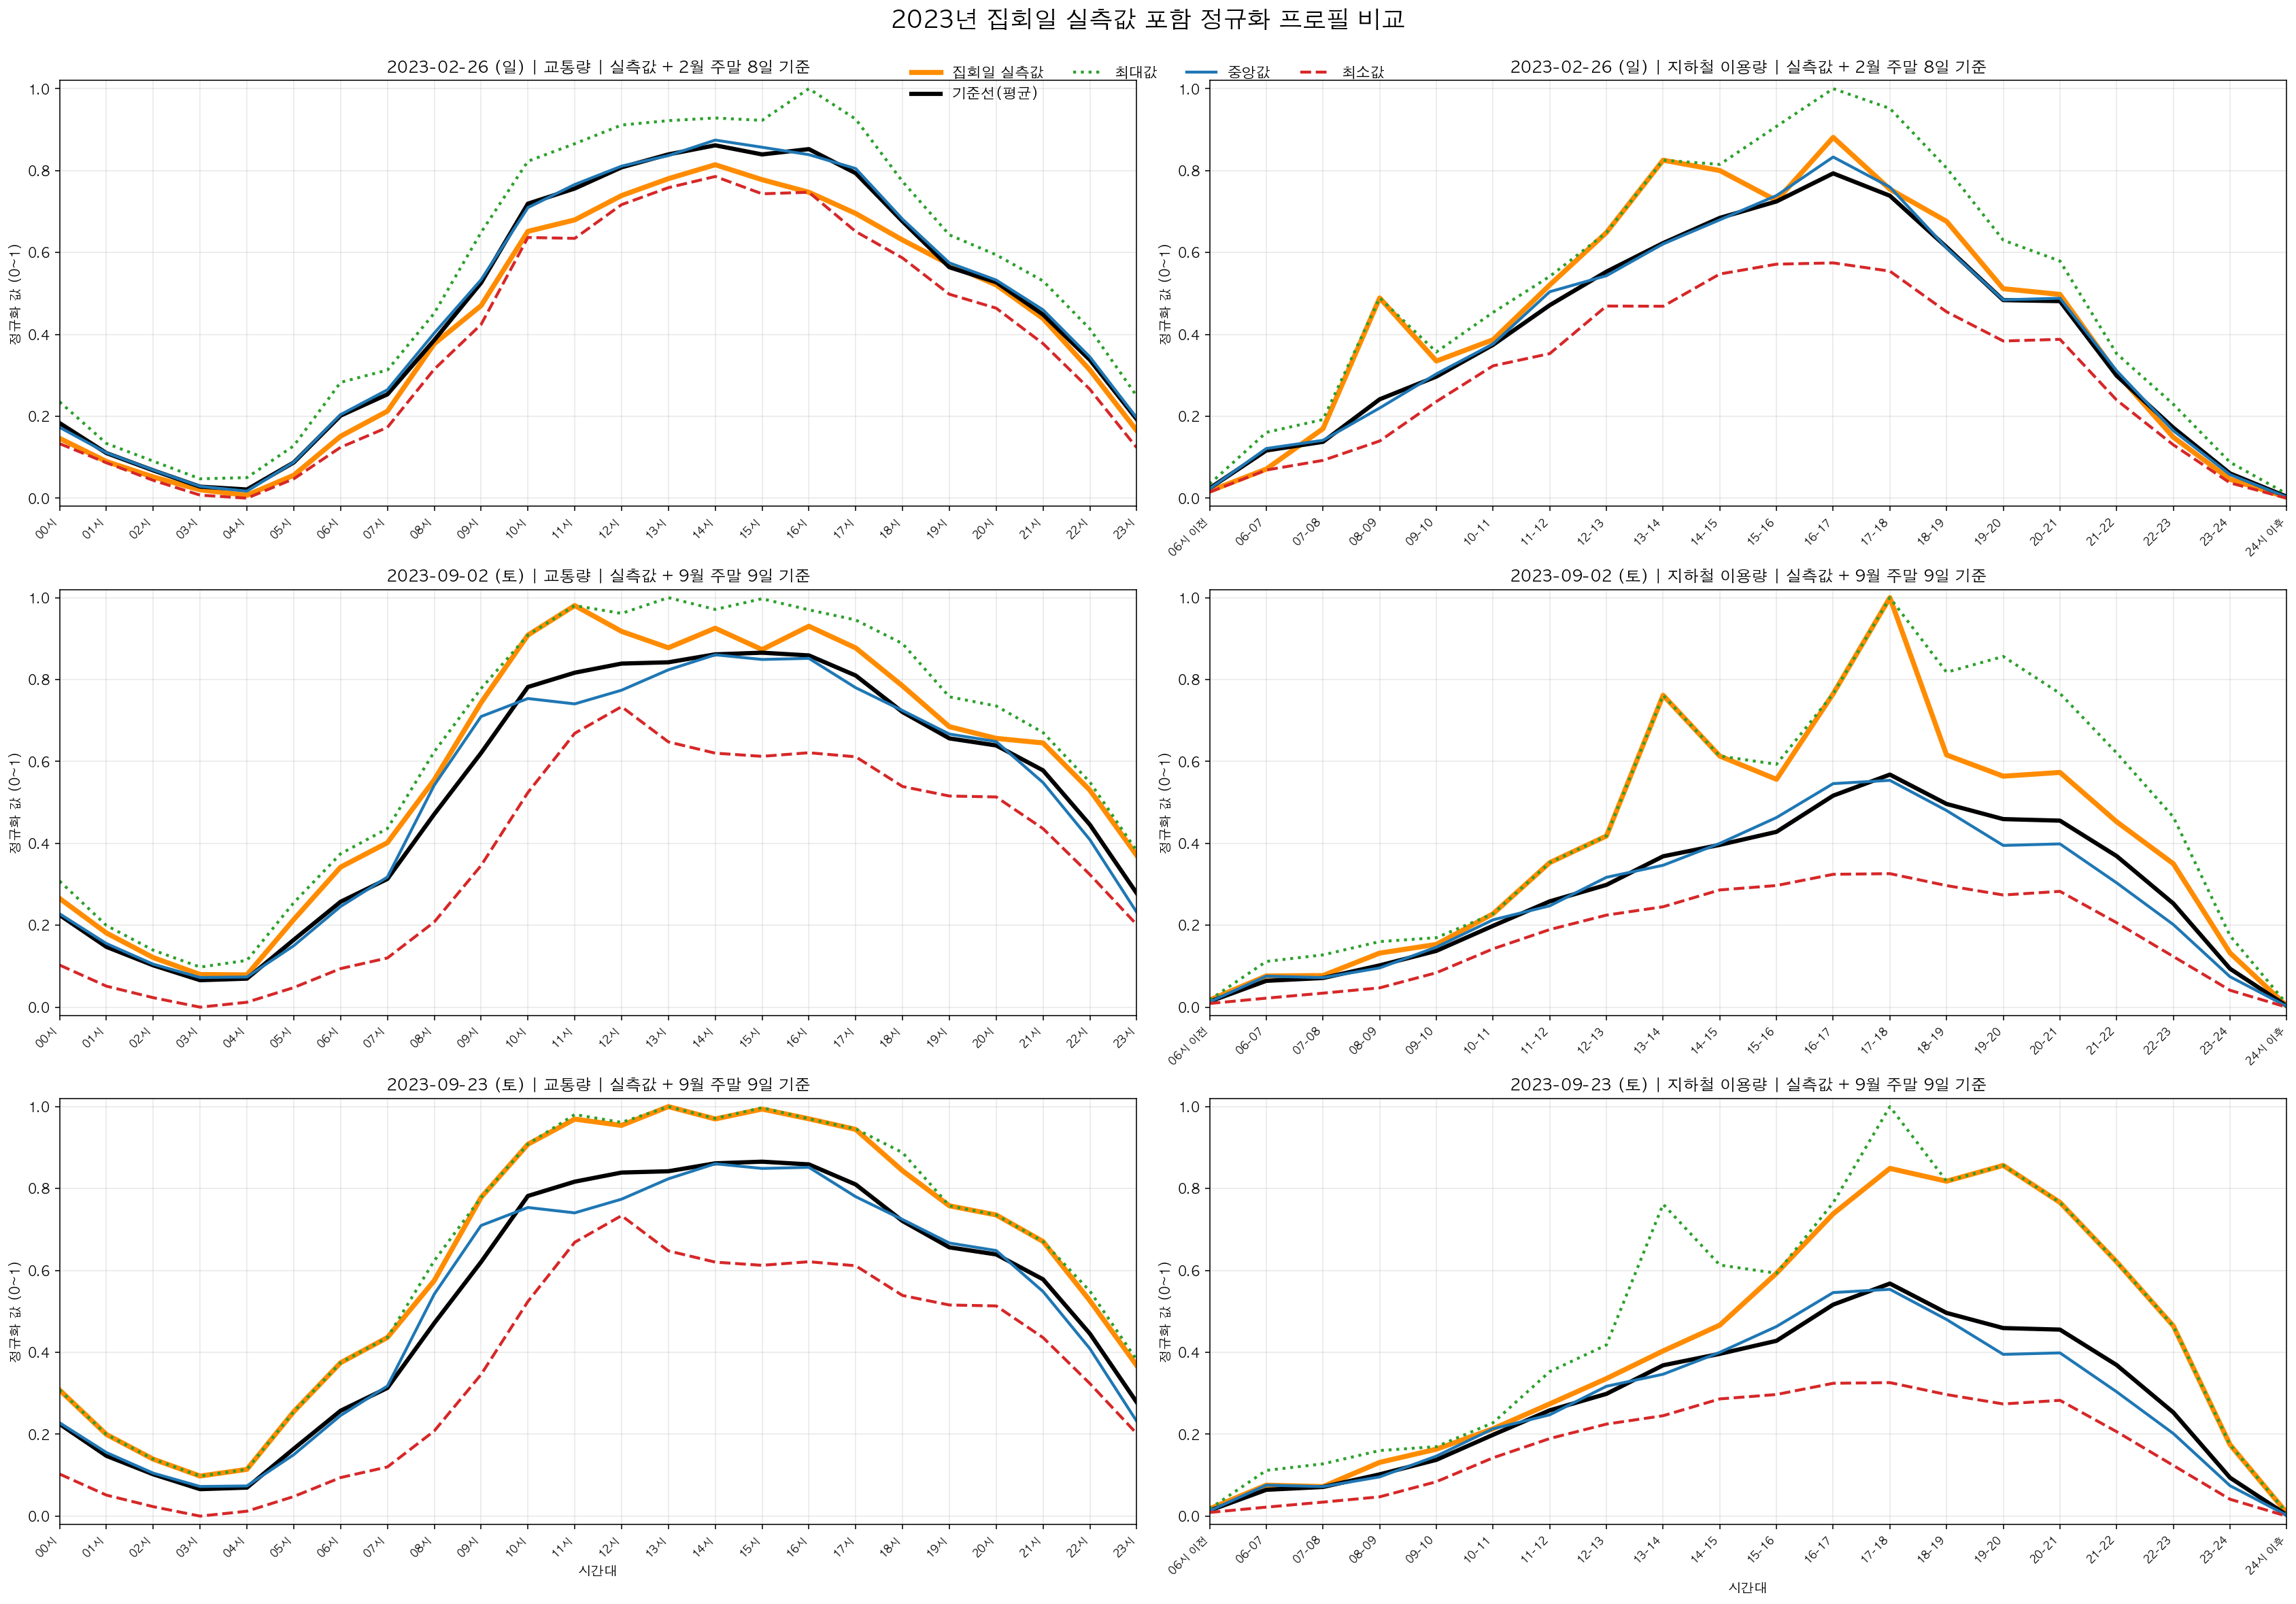

저장 완료: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/outputs/assembly_event_profiles_2023.png


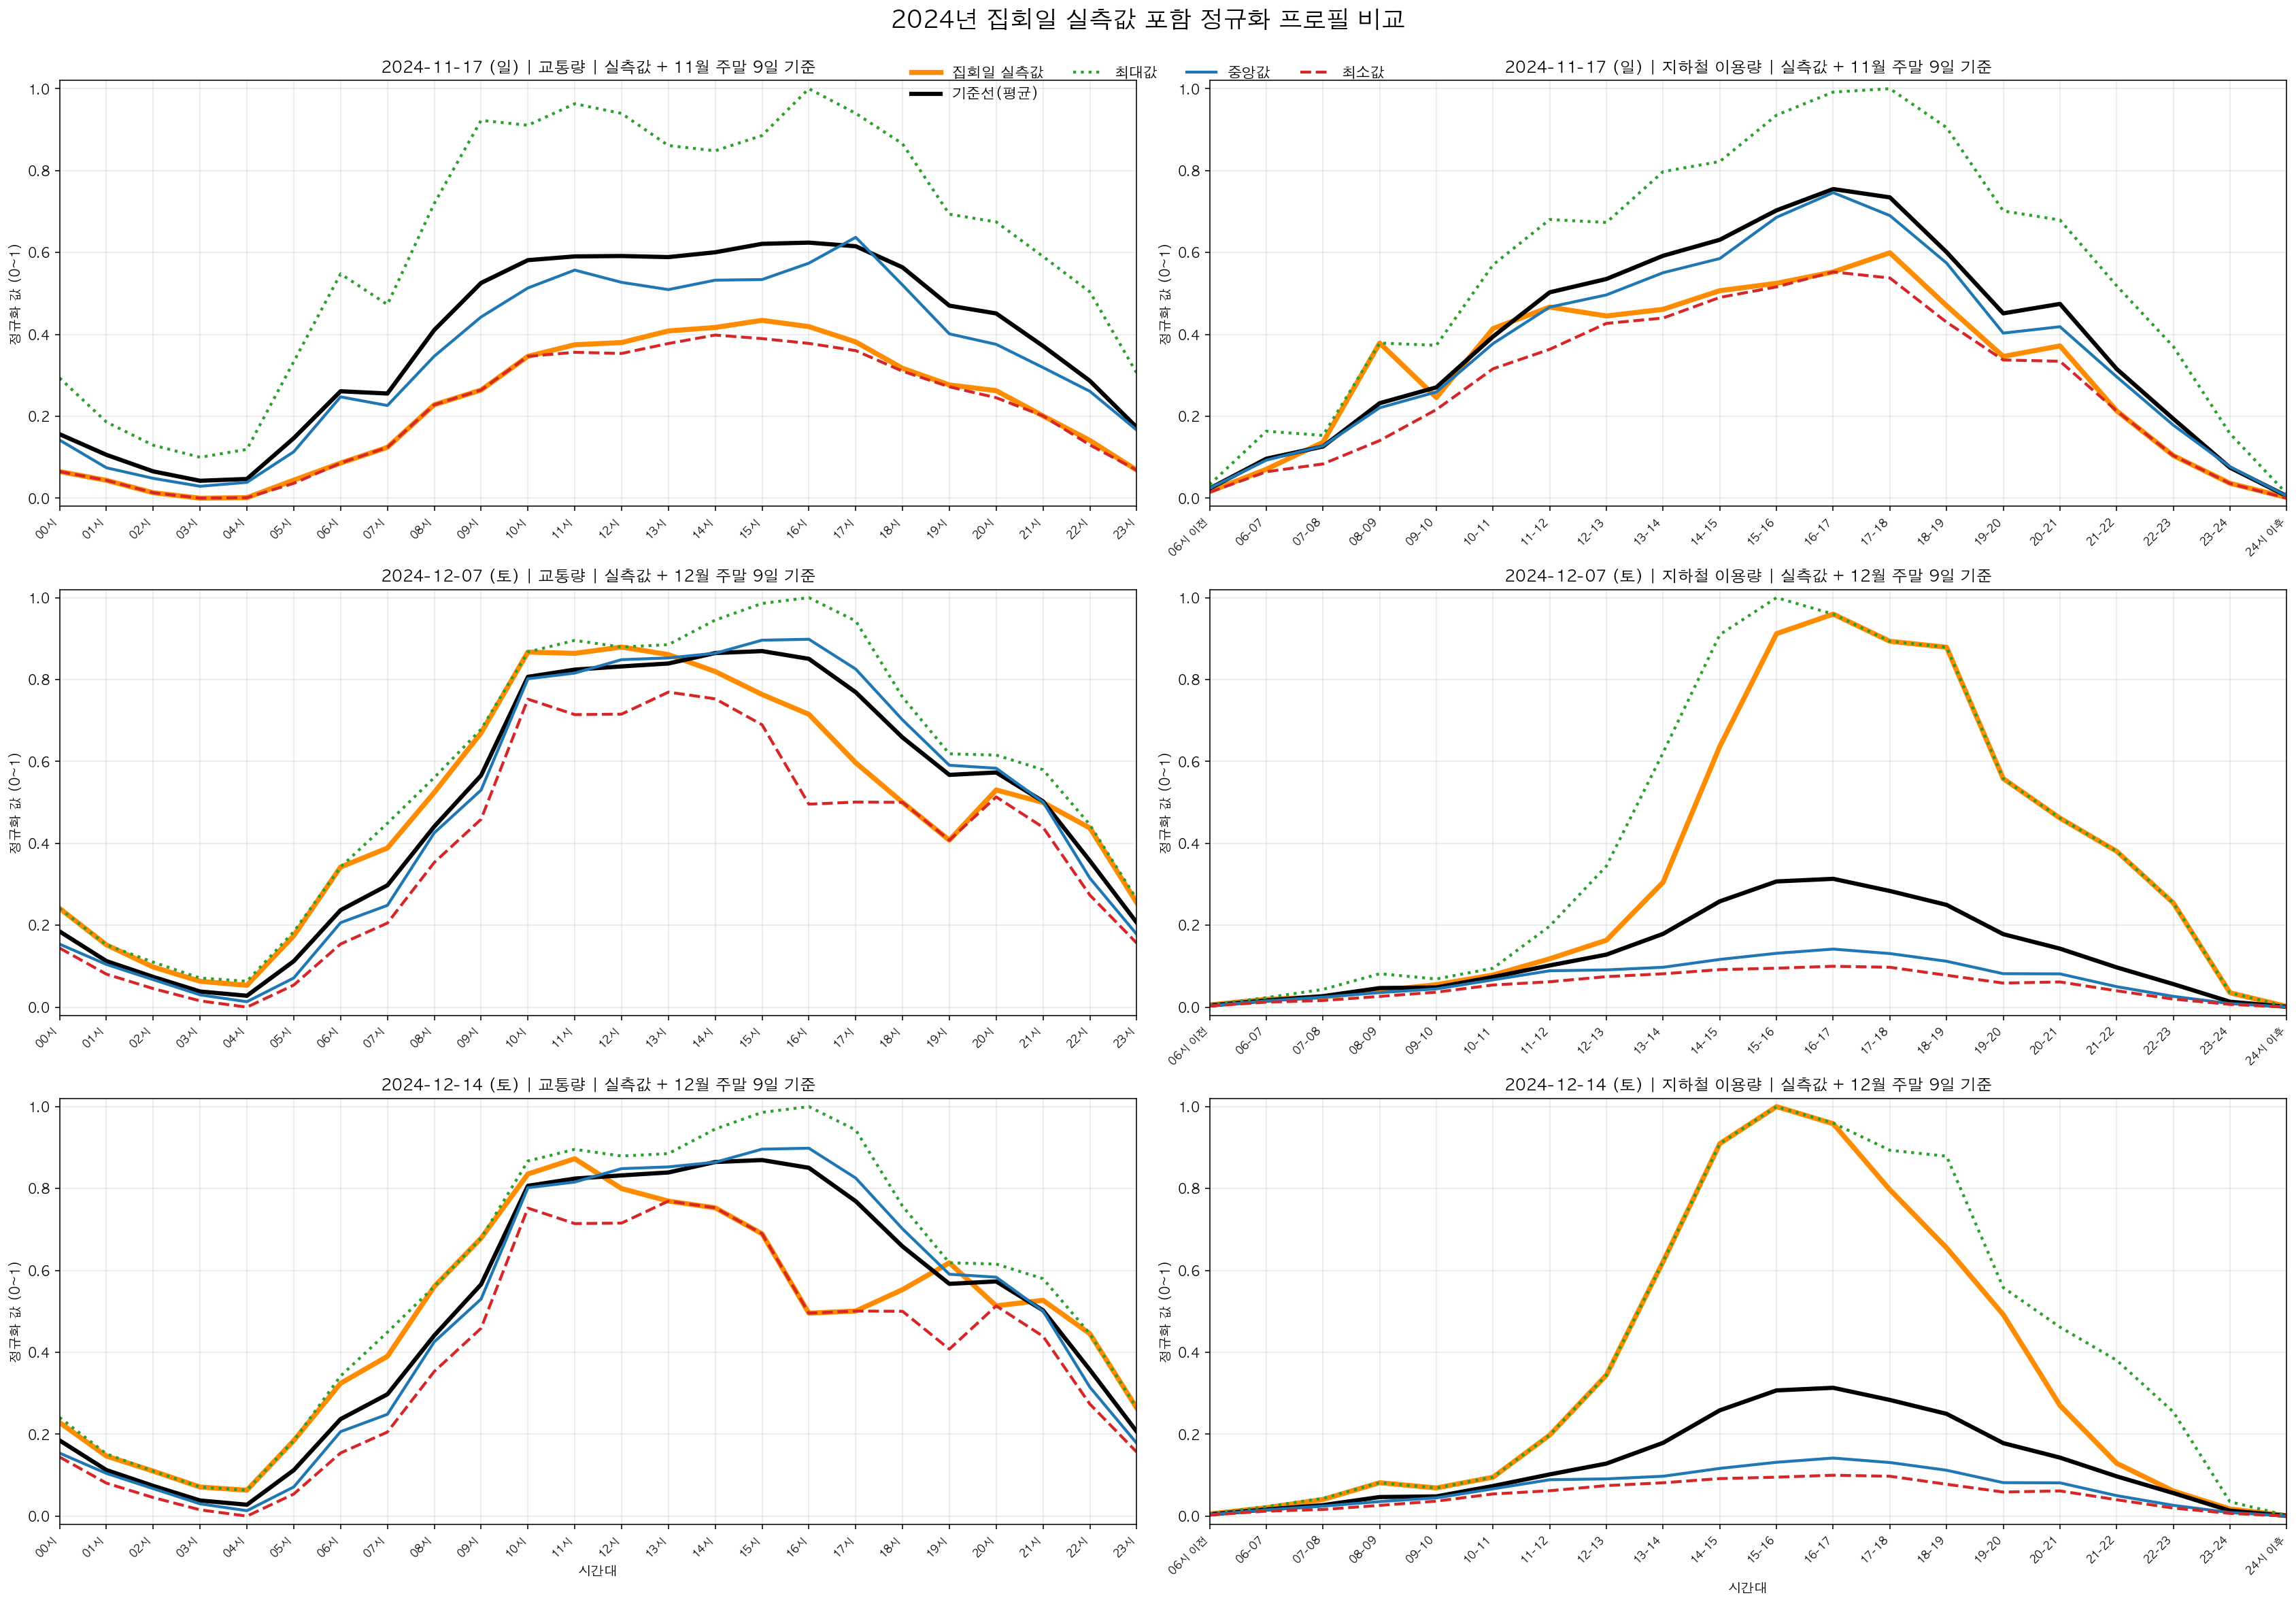

저장 완료: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/outputs/assembly_event_profiles_2024.png


In [4]:
style_map = {
    '집회일 실측값': {'color': '#ff8c00', 'linewidth': 3.8, 'linestyle': '-'},
    '기준선(평균)': {'color': 'black', 'linewidth': 3.2, 'linestyle': '-'},
    '최대값': {'color': '#2ca02c', 'linewidth': 2.2, 'linestyle': ':'},
    '중앙값': {'color': '#1f77b4', 'linewidth': 2.2, 'linestyle': '-'},
    '최소값': {'color': '#d62728', 'linewidth': 2.2, 'linestyle': '--'},
}

legend_handles = [
    Line2D([0], [0], label=label, **style)
    for label, style in style_map.items()
]


def plot_event_panels(year, year_events):
    fig, axes = plt.subplots(
        len(year_events),
        2,
        figsize=(24, 5.4 * len(year_events)),
        constrained_layout=True,
    )

    if len(year_events) == 1:
        axes = axes.reshape(1, -1)

    for row_idx, event in enumerate(year_events.itertuples(index=False)):
        panel_specs = [
            ('교통량', traffic_data[event.연도]),
            ('지하철 이용량', subway_data[event.연도]),
        ]

        for col_idx, (metric_name, data_bundle) in enumerate(panel_specs):
            daily_df, hour_cols, tick_labels = data_bundle
            subset = daily_df[(daily_df['월'] == event.월) & (daily_df['구분'] == event.구분)].copy()
            stats_df = build_monthly_stats(subset, hour_cols, event.집회일)

            ax = axes[row_idx, col_idx]
            for stat_name, style in style_map.items():
                ax.plot(range(len(hour_cols)), stats_df.loc[stat_name].values, **style)

            ax.set_xlim(0, len(hour_cols) - 1)
            ax.set_xticks(range(len(hour_cols)))
            ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
            ax.grid(alpha=0.28)
            ax.set_ylim(-0.02, 1.02)
            ax.set_ylabel('정규화 값 (0~1)', fontsize=10)
            if row_idx == len(year_events) - 1:
                ax.set_xlabel('시간대', fontsize=10)

            ax.set_title(
                f"{event.집회일:%Y-%m-%d} ({event.요일}) | {metric_name} | 실측값 + {event.월}월 {event.구분} {len(subset)}일 기준",
                fontsize=12,
            )

    fig.suptitle(
        f'{year}년 집회일 실측값 포함 정규화 프로필 비교',
        fontsize=18,
        fontweight='bold',
        y=1.03,
    )
    fig.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.002),
        ncol=4,
        frameon=False,
        fontsize=11,
    )

    output_path = project_root / 'outputs' / f'assembly_event_profiles_{year}.png'
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'저장 완료: {output_path}')


for year, year_events in event_dates.groupby('연도', sort=True):
    plot_event_panels(year, year_events.reset_index(drop=True))